## Part B: Dataset Understanding & Preparation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('RealEstate_HousePrice_Dataset_4200.csv')
df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [4]:
df.shape

(4200, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB


In [6]:
df.describe()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4.200000e+03
mean,102100.500000,1667.357381,3.696667,2.827381,5.611429,23.829524,18.186167,3366.329048,0.642381,0.096190,7.955714,2.364189e+07
std,1212.579894,630.336132,1.574199,1.153585,2.140880,13.945663,8.674549,1658.230565,0.479356,0.294887,7.316766,1.239279e+07
min,100001.000000,450.000000,1.000000,1.000000,1.000000,1.000000,1.000000,800.000000,0.000000,0.000000,0.000000,8.000000e+05
25%,101050.750000,1226.750000,3.000000,2.000000,4.000000,13.000000,11.800000,2122.500000,0.000000,0.000000,2.000000,1.425969e+07
50%,102100.500000,1660.000000,4.000000,3.000000,5.700000,21.000000,17.800000,3188.000000,1.000000,0.000000,6.000000,2.214500e+07
75%,103150.250000,2084.250000,5.000000,4.000000,7.300000,32.000000,24.200000,4364.250000,1.000000,0.000000,12.000000,3.096090e+07
max,104200.000000,4202.000000,7.000000,6.000000,10.000000,80.000000,47.600000,12938.000000,1.000000,1.000000,50.000000,7.611172e+07


In [7]:
# Identify independent and dependent variables.

X = df.drop(columns=['house_id', 'house_price_inr'])
print("Independent Variables:", list(X.columns))

y = df['house_price_inr']
print("\nDependent Variable: house_price_inr")

Independent Variables: ['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage', 'has_pool', 'renovation_years_ago']

Dependent Variable: house_price_inr


In [8]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
house_id                0
area_sqft               0
bedrooms                0
bathrooms               0
location_score          0
age_years               0
distance_city_km        0
lot_size_sqft           0
has_garage              0
has_pool                0
renovation_years_ago    0
house_price_inr         0
dtype: int64


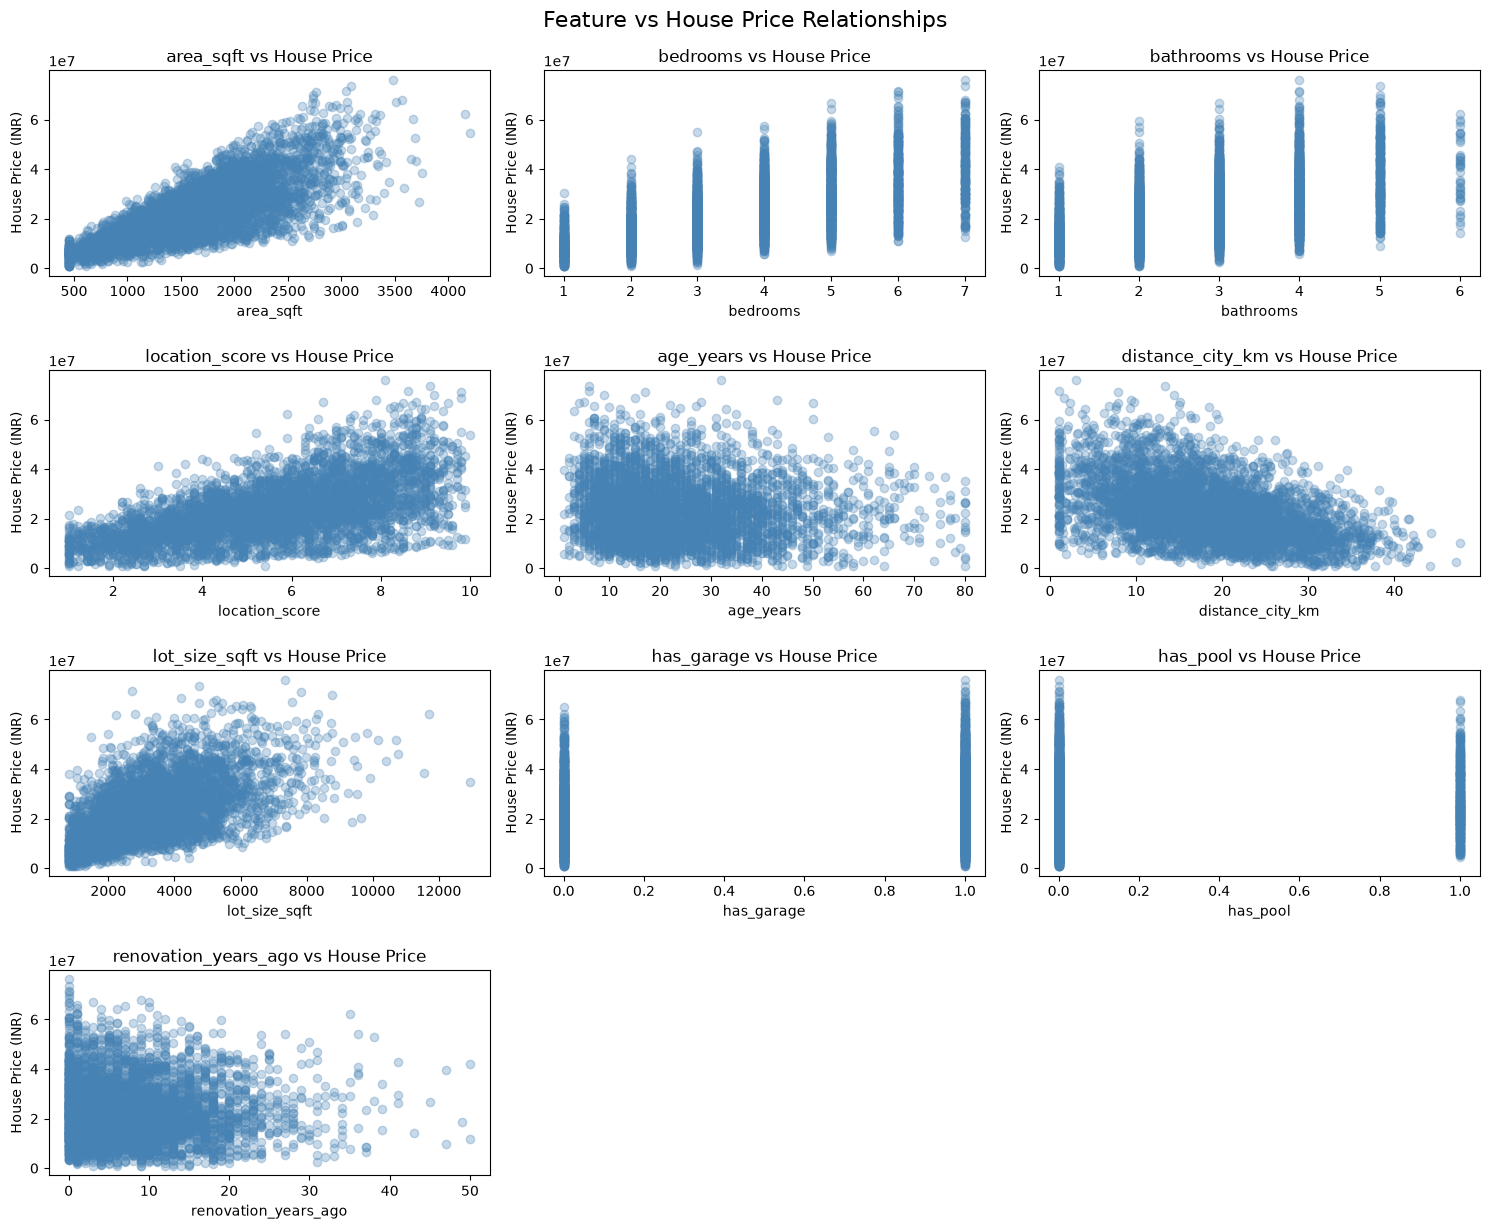

In [9]:
# Visualize relationships between features and target variable.

features = ['area_sqft', 'bedrooms', 'bathrooms', 'location_score',
            'age_years', 'distance_city_km', 'lot_size_sqft',
            'has_garage', 'has_pool', 'renovation_years_ago']

plt.figure(figsize=(15, 12))

for i, feature in enumerate(features):
    plt.subplot(4, 3, i+1)
    plt.scatter(df[feature], df['house_price_inr'], alpha=0.3, color='steelblue')
    plt.xlabel(feature)
    plt.ylabel('House Price (INR)')
    plt.title(f'{feature} vs House Price')

plt.tight_layout()
plt.suptitle('Feature vs House Price Relationships', fontsize=16, y=1.02)
plt.show()

In [10]:
# Split the dataset into training and testing sets.

from sklearn.model_selection import train_test_split

X = df.drop(columns=['house_id', 'house_price_inr'])
y = df['house_price_inr']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (4200, 10)
Shape of y: (4200,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (3360, 10)
Testing set size: (840, 10)


## Part C — Simple Linear Regression

In [12]:
# Implement Simple Linear Regression using House Area

from sklearn.linear_model import LinearRegression

X_simple = df[['area_sqft']]
y_simple = df['house_price_inr']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y_simple, test_size=0.2, random_state=2)

lr = LinearRegression()
lr.fit(X_train_s, y_train_s)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[14831.44]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['area_sqft']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.049e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


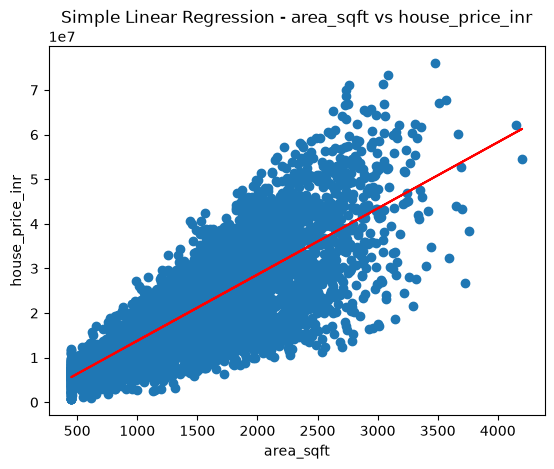

Slope: 14831.436913160367
Intercept: -1048695.902138304


In [13]:
# Plot Regression Line — Slope and Intercept

y_pred_s = lr.predict(X_test_s)

plt.scatter(df['area_sqft'], df['house_price_inr'])
plt.plot(X_train_s, lr.predict(X_train_s), color='red')
plt.xlabel('area_sqft')
plt.ylabel('house_price_inr')
plt.title('Simple Linear Regression - area_sqft vs house_price_inr')
plt.show()

print("Slope:", lr.coef_[0])
print("Intercept:", lr.intercept_)

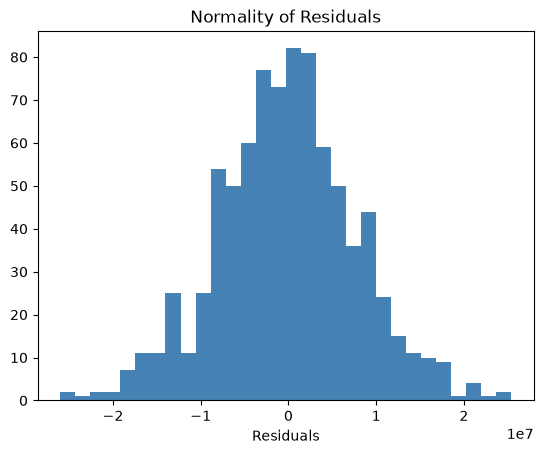

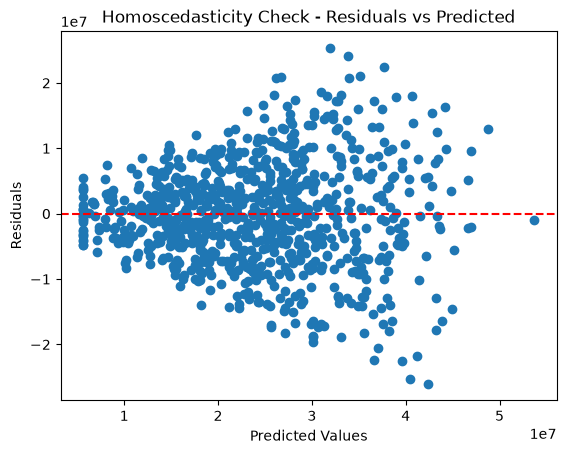

In [14]:
# Validate Linear Regression Assumptions

residuals = y_test_s - y_pred_s

plt.hist(residuals, bins=30, color='steelblue')
plt.title('Normality of Residuals')
plt.xlabel('Residuals')
plt.show()

plt.scatter(y_pred_s, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Homoscedasticity Check - Residuals vs Predicted')
plt.show()

## Part D: Model Evaluation Metrics

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE: ", mean_absolute_error(y_test_s, y_pred_s))
print("MSE: ", mean_squared_error(y_test_s, y_pred_s))
print("RMSE: ", np.sqrt(mean_squared_error(y_test_s, y_pred_s)))

r2 = r2_score(y_test_s, y_pred_s)
print("R2 Score:", r2)

n = X_test_s.shape[0]
k = X_test_s.shape[1]
print("Adjusted R2:", 1 - ((1 - r2) * (n - 1) / (n - k - 1)))

MAE:  6137347.122366971
MSE:  62108732040612.83
RMSE:  7880909.340971562
R2 Score: 0.5841883679421702
Adjusted R2: 0.5836921726771848


## Part E: Multiple Linear Regression

In [16]:
# Implement Multiple Linear Regression

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred_m = model.predict(X_test)

In [17]:

# Compare Performance with Simple Linear Regression

r2_m = r2_score(y_test, y_pred_m)
n = X_test.shape[0]
k = X_test.shape[1]

print("--- Multiple Linear Regression ---")
print("MAE: ", mean_absolute_error(y_test, y_pred_m))
print("MSE: ", mean_squared_error(y_test, y_pred_m))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred_m)))
print("R2 Score:", r2_m)
print("Adjusted R2:", 1 - ((1 - r2_m) * (n - 1) / (n - k - 1)))

print()
print("--- Simple Linear Regression ---")
print("R2 Score:", r2_score(y_test_s, y_pred_s))

--- Multiple Linear Regression ---
MAE:  2525453.895990639
MSE:  11055935813044.2
RMSE:  3325046.738475145
R2 Score: 0.9259816363447506
Adjusted R2: 0.9250887730919732

--- Simple Linear Regression ---
R2 Score: 0.5841883679421702


In [18]:
# Why Performance Changes

coeff_df = pd.DataFrame(model.coef_, index=X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
area_sqft,1.380254e+04
bedrooms,2.585363e+05
bathrooms,1.626715e+05
location_score,3.124821e+06
age_years,-6.277482e+04
distance_city_km,-9.182109e+04
lot_size_sqft,1.172294e+02
has_garage,1.041791e+05
has_pool,3.524039e+05
renovation_years_ago,-2.853338e+04


## Part F: Polynomial Regression

Degree 1 - R2 Score: 0.5841883679421702
Degree 2 - R2 Score: 0.5841864691357137
Degree 3 - R2 Score: 0.5806515486343605


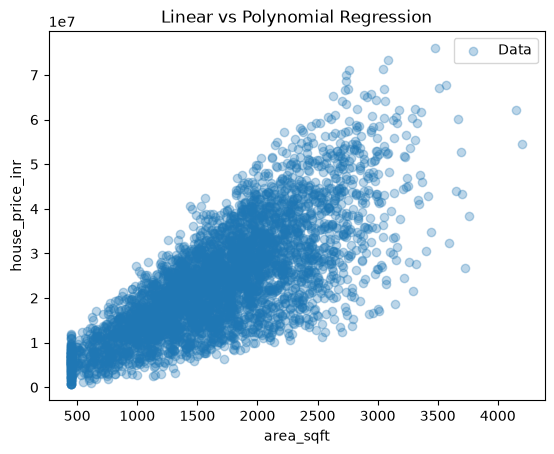

In [19]:
# Implement Polynomial Regression and Compare

from sklearn.preprocessing import PolynomialFeatures

X_poly = df[['area_sqft']]
y_poly = df['house_price_inr']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y_poly, test_size=0.2, random_state=2)

plt.scatter(df['area_sqft'], df['house_price_inr'], alpha=0.3, label='Data')

for degree in [1, 2, 3]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_p)
    X_test_poly = poly.transform(X_test_p)

    model_poly = LinearRegression()
    model_poly.fit(X_train_poly, y_train_p)

    y_pred_poly = model_poly.predict(X_test_poly)
    r2_poly = r2_score(y_test_p, y_pred_poly)

    print(f"Degree {degree} - R2 Score:", r2_poly)

plt.xlabel('area_sqft')
plt.ylabel('house_price_inr')
plt.title('Linear vs Polynomial Regression')
plt.legend()
plt.show()

In [20]:
# Overfitting and Underfitting Check

for degree in [1, 2, 3]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_p)
    X_test_poly = poly.transform(X_test_p)

    model_poly = LinearRegression()
    model_poly.fit(X_train_poly, y_train_p)

    train_r2 = r2_score(y_train_p, model_poly.predict(X_train_poly))
    test_r2 = r2_score(y_test_p, model_poly.predict(X_test_poly))

    print(f"Degree {degree} — Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")

Degree 1 — Train R2: 0.5674 | Test R2: 0.5842
Degree 2 — Train R2: 0.5676 | Test R2: 0.5842
Degree 3 — Train R2: 0.5647 | Test R2: 0.5807


## Part G: Gradient Descent Optimization

What is Gradient Descent?

Gradient Descent is an optimization algorithm used to minimize the cost/error function.
It updates weights (m) and bias (c) step by step using the formula:
w = w - α * (∂J/∂w)
where α is the learning rate.

In [24]:
# Batch Gradient Descent

import random

X_gd = df['area_sqft'].values.astype(float)
Y_gd = df['house_price_inr'].values.astype(float)

X_gd = (X_gd - X_gd.mean()) / X_gd.std()
Y_gd = (Y_gd - Y_gd.mean()) / Y_gd.std()

def gradient_descent(x, y):
    m = 0
    c = 0
    rate = 0.001
    iteration = 100
    n = len(x)

    for i in range(iteration):
        y_predicted = m * x + c
        cost = (1/n) * sum([val**2 for val in (y - y_predicted)])

        mp = -(2/n) * sum(x * (y - y_predicted))
        cp = -(2/n) * sum(y - y_predicted)

        m = m - rate * mp
        c = c - rate * cp

        print(f"Iteration {i+1}: m={m:.4f}, c={c:.4f}, cost={cost:.4f}")

    return m, c

m, c = gradient_descent(X_gd, Y_gd)

Iteration 1: m=0.0015, c=0.0000, cost=1.0000
Iteration 2: m=0.0030, c=0.0000, cost=0.9977
Iteration 3: m=0.0045, c=0.0000, cost=0.9954
Iteration 4: m=0.0060, c=0.0000, cost=0.9932
Iteration 5: m=0.0075, c=0.0000, cost=0.9909
Iteration 6: m=0.0090, c=0.0000, cost=0.9887
Iteration 7: m=0.0105, c=0.0000, cost=0.9865
Iteration 8: m=0.0120, c=0.0000, cost=0.9842
Iteration 9: m=0.0135, c=0.0000, cost=0.9820
Iteration 10: m=0.0150, c=0.0000, cost=0.9798
Iteration 11: m=0.0165, c=0.0000, cost=0.9776
Iteration 12: m=0.0179, c=0.0000, cost=0.9754
Iteration 13: m=0.0194, c=0.0000, cost=0.9732
Iteration 14: m=0.0209, c=0.0000, cost=0.9711
Iteration 15: m=0.0223, c=0.0000, cost=0.9689
Iteration 16: m=0.0238, c=0.0000, cost=0.9667
Iteration 17: m=0.0253, c=0.0000, cost=0.9646
Iteration 18: m=0.0267, c=0.0000, cost=0.9624
Iteration 19: m=0.0282, c=0.0000, cost=0.9603
Iteration 20: m=0.0297, c=0.0000, cost=0.9582
Iteration 21: m=0.0311, c=0.0000, cost=0.9561
Iteration 22: m=0.0326, c=0.0000, cost=0.95

Epoch 1: m=0.7712, c=0.0190, cost=0.4299
Epoch 2: m=0.7815, c=0.0140, cost=0.4302
Epoch 3: m=0.7869, c=0.0256, cost=0.4310
Epoch 4: m=0.7265, c=-0.0191, cost=0.4305
Epoch 5: m=0.7554, c=0.0067, cost=0.4294
Epoch 6: m=0.7894, c=0.0161, cost=0.4307
Epoch 7: m=0.7827, c=0.0107, cost=0.4302
Epoch 8: m=0.7596, c=-0.0101, cost=0.4294
Epoch 9: m=0.7560, c=-0.0049, cost=0.4293
Epoch 10: m=0.7236, c=0.0042, cost=0.4303
Epoch 11: m=0.7825, c=-0.0135, cost=0.4302
Epoch 12: m=0.7374, c=0.0055, cost=0.4297
Epoch 13: m=0.7556, c=-0.0000, cost=0.4293
Epoch 14: m=0.7831, c=-0.0144, cost=0.4303
Epoch 15: m=0.7678, c=-0.0217, cost=0.4299
Epoch 16: m=0.7375, c=0.0157, cost=0.4299
Epoch 17: m=0.7105, c=-0.0243, cost=0.4319
Epoch 18: m=0.7958, c=0.0215, cost=0.4314
Epoch 19: m=0.7899, c=0.0536, cost=0.4334
Epoch 20: m=0.7697, c=0.0088, cost=0.4296
Epoch 21: m=0.7839, c=-0.0042, cost=0.4301
Epoch 22: m=0.7649, c=-0.0212, cost=0.4299
Epoch 23: m=0.7664, c=0.0262, cost=0.4301
Epoch 24: m=0.7768, c=0.0520, cos

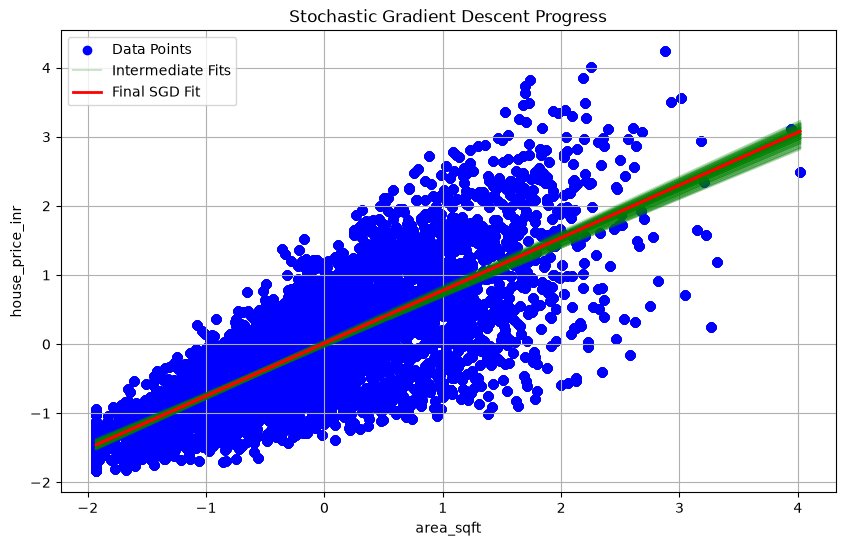


Final m (SGD): 0.7627
Final c (SGD): 0.0128


In [25]:
# Stochastic Gradient Descent (SGD)

def stochastic_gradient_descent(x, y, rate=0.001, epochs=100):
    m = 0
    c = 0
    n = len(x)

    plt.figure(figsize=(10, 6))

    for epoch in range(epochs):
        data_indices = list(range(n))
        random.shuffle(data_indices)

        for i in data_indices:
            x_i = x[i]
            y_i = y[i]

            y_predicted_i = m * x_i + c

            mp_i = -2 * x_i * (y_i - y_predicted_i)
            cp_i = -2 * (y_i - y_predicted_i)

            m = m - rate * mp_i
            c = c - rate * cp_i

        y_predicted = m * x + c
        cost = (1/n) * sum([val**2 for val in (y - y_predicted)])
        print(f"Epoch {epoch+1}: m={m:.4f}, c={c:.4f}, cost={cost:.4f}")

        plt.scatter(X_gd, Y_gd, color='blue', label='Data Points' if epoch == 0 else "")
        plt.plot(X_gd, y_predicted, color='green', alpha=0.2, label='Intermediate Fits' if epoch == 0 else "")

    plt.plot(X_gd, y_predicted, color='red', linewidth=2, label='Final SGD Fit')
    plt.title('Stochastic Gradient Descent Progress')
    plt.xlabel('area_sqft')
    plt.ylabel('house_price_inr')
    plt.legend()
    plt.grid(True)
    plt.show()

    return m, c

m_sgd, c_sgd = stochastic_gradient_descent(X_gd, Y_gd, rate=0.001, epochs=100)
print(f"\nFinal m (SGD): {m_sgd:.4f}")
print(f"Final c (SGD): {c_sgd:.4f}")

Epoch 1: m=0.6616, c=-0.0047, cost=0.4382
Epoch 2: m=0.7427, c=0.0085, cost=0.4296
Epoch 3: m=0.7502, c=-0.0051, cost=0.4294
Epoch 4: m=0.7554, c=-0.0021, cost=0.4293
Epoch 5: m=0.7542, c=-0.0018, cost=0.4293
Epoch 6: m=0.7662, c=0.0139, cost=0.4296
Epoch 7: m=0.7633, c=-0.0045, cost=0.4294
Epoch 8: m=0.7602, c=-0.0005, cost=0.4293
Epoch 9: m=0.7671, c=-0.0007, cost=0.4295
Epoch 10: m=0.7669, c=0.0077, cost=0.4295
Epoch 11: m=0.7497, c=-0.0031, cost=0.4294
Epoch 12: m=0.7588, c=0.0004, cost=0.4293
Epoch 13: m=0.7477, c=0.0008, cost=0.4294
Epoch 14: m=0.7501, c=-0.0050, cost=0.4294
Epoch 15: m=0.7620, c=0.0061, cost=0.4294
Epoch 16: m=0.7473, c=-0.0012, cost=0.4294
Epoch 17: m=0.7605, c=0.0100, cost=0.4294
Epoch 18: m=0.7583, c=0.0064, cost=0.4294
Epoch 19: m=0.7501, c=0.0019, cost=0.4294
Epoch 20: m=0.7511, c=0.0028, cost=0.4293
Epoch 21: m=0.7430, c=-0.0032, cost=0.4295
Epoch 22: m=0.7635, c=-0.0006, cost=0.4294
Epoch 23: m=0.7544, c=-0.0027, cost=0.4293
Epoch 24: m=0.7561, c=0.0043, 

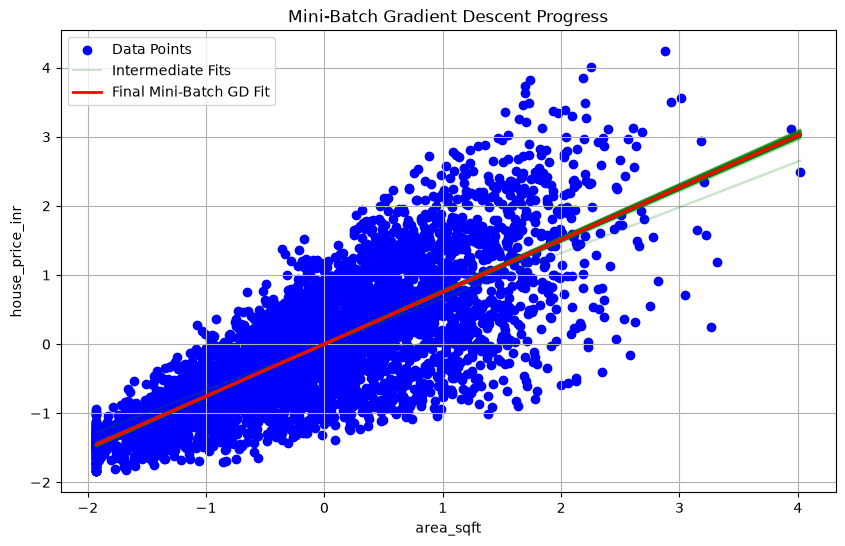


Final m (Mini-Batch GD): 0.7545
Final c (Mini-Batch GD): 0.0024


In [26]:
# Mini-Batch Gradient Descent

def mini_batch_gradient_descent(x, y, learning_rate=0.001, num_epochs=100, batch_size=4):
    m = 0
    c = 0
    n = len(x)

    if batch_size > n:
        batch_size = n

    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color='blue', label='Data Points')

    for epoch in range(num_epochs):
        data_indices = list(range(n))
        random.shuffle(data_indices)

        for i in range(0, n, batch_size):
            batch_indices = data_indices[i:i + batch_size]
            x_batch = x[np.array(batch_indices)]
            y_batch = y[np.array(batch_indices)]

            n_batch = len(x_batch)
            y_predicted_batch = m * x_batch + c

            mp_batch = -(2/n_batch) * np.sum(x_batch * (y_batch - y_predicted_batch))
            cp_batch = -(2/n_batch) * np.sum(y_batch - y_predicted_batch)

            m = m - learning_rate * mp_batch
            c = c - learning_rate * cp_batch

        y_predicted_full = m * x + c
        cost_full = (1/n) * np.sum((y - y_predicted_full)**2)
        print(f"Epoch {epoch+1}: m={m:.4f}, c={c:.4f}, cost={cost_full:.4f}")

        plt.plot(x, y_predicted_full, color='green', alpha=0.2, label='Intermediate Fits' if epoch == 0 else "")

    plt.plot(x, y_predicted_full, color='red', linewidth=2, label='Final Mini-Batch GD Fit')
    plt.title('Mini-Batch Gradient Descent Progress')
    plt.xlabel('area_sqft')
    plt.ylabel('house_price_inr')
    plt.legend()
    plt.grid(True)
    plt.show()

    return m, c

m_mbgd, c_mbgd = mini_batch_gradient_descent(X_gd, Y_gd, learning_rate=0.001, num_epochs=100, batch_size=4)
print(f"\nFinal m (Mini-Batch GD): {m_mbgd:.4f}")
print(f"Final c (Mini-Batch GD): {c_mbgd:.4f}")

## Part H: Bias-Variance & Model Diagnostics

In [27]:
# Bias-Variance Analysis Across Models

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

models = {
    'Simple LR': make_pipeline(PolynomialFeatures(degree=1), LinearRegression()),
    'Multiple LR': LinearRegression(),
    'Polynomial d2': make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    'Polynomial d3': make_pipeline(PolynomialFeatures(degree=3), LinearRegression()),
}

print(f"{'Model':<20} {'Train R2':<15} {'Test R2':<15} {'Diagnosis'}")
print("-" * 65)

for name, m in models.items():
    if name == 'Multiple LR':
        m.fit(X_train, y_train)
        train_r2 = r2_score(y_train, m.predict(X_train))
        test_r2 = r2_score(y_test, m.predict(X_test))
    else:
        m.fit(X_train_p, y_train_p)
        train_r2 = r2_score(y_train_p, m.predict(X_train_p))
        test_r2 = r2_score(y_test_p, m.predict(X_test_p))

    if train_r2 < 0.7:
        diagnosis = 'High Bias (Underfitting)'
    elif train_r2 - test_r2 > 0.1:
        diagnosis = 'High Variance (Overfitting)'
    else:
        diagnosis = 'Good Fit'

    print(f"{name:<20} {train_r2:<15.4f} {test_r2:<15.4f} {diagnosis}")

Model                Train R2        Test R2         Diagnosis
-----------------------------------------------------------------
Simple LR            0.5674          0.5842          High Bias (Underfitting)
Multiple LR          0.9228          0.9260          Good Fit
Polynomial d2        0.5676          0.5842          High Bias (Underfitting)
Polynomial d3        0.5647          0.5807          High Bias (Underfitting)


In [28]:
# Best Model — Bias-Variance Balance

print("Best Model: Multiple Linear Regression")
print("- Highest Test R2 among all models")
print("- Train R2 and Test R2 are close — low variance")
print("- Uses all features — low bias")
print("- Polynomial models risk overfitting with higher degrees")

Best Model: Multiple Linear Regression
- Highest Test R2 among all models
- Train R2 and Test R2 are close — low variance
- Uses all features — low bias
- Polynomial models risk overfitting with higher degrees


## Part I: Final Analysis & Report

### 1. Best Performing Model
Multiple Linear Regression is the best performing model with Test R² of 0.926.
It uses all 10 features which allows it to capture more patterns in the data.
Train R² (0.922) and Test R² (0.926) are very close — confirming low bias and low variance.

### 2. Impact of Gradient Descent Optimization
All three gradient descent methods (Batch, SGD, Mini-Batch) successfully minimized the cost function.
SGD and Mini-Batch converged to similar final weights (m ≈ 0.76) faster than Batch GD.
Batch GD was slower but more stable. Mini-Batch gave the best balance of speed and stability.
Data normalization was essential — without it, large feature values caused gradients to explode to NaN.

### 3. Evidence of Overfitting / Underfitting
Simple LR and Polynomial Regression (degree 2 & 3) showed High Bias (Underfitting) with R² ≈ 0.58.
This is because they used only one feature (area_sqft) which is not enough to explain house prices.
No overfitting was observed — Train R² and Test R² remained close across all models.

### 4. Business Interpretation
The model can predict house prices in INR with 92.6% accuracy using 10 property features.
Location score has the highest positive impact on price (coefficient: 3.12M per unit).
Age of property and distance from city negatively impact price — older and farther houses cost less.
This system can help the real estate firm price properties accurately and make data-driven decisions.